# 전체 코드 흐름 개요 (MLP + Two-Stage 보정)

이 노트북은 **Stage1 MLP 학습/평가** 후, **경계 샘플만 선택적으로 보정(Two-Stage)** 하여 디지털 소외계층을 3단계로 분류하는 성능을 개선하는 실험 파이프라인을 갖는다.

---
## 1) 파이프라인 단계 (메인 실행 흐름)

**단계 1. 환경/재현성/경로 초기화**
- 라이브러리 import
- 시드 고정 및 결정론 옵션 설정
- 프로젝트 루트/입출력 경로 설정

**단계 2. 데이터 로딩 및 라벨 정규화**
- train/val/test 데이터 로드
- 라벨을 0-based(0,1,2)로 변환

**단계 3. 텐서 변환/로더 구성/모델 정의**
- DataFrame → Tensor 변환
- DataLoader 구성(학습 셔플 포함)
- MLP 아키텍처 정의

**단계 4. Stage1 MLP 학습/검증/모델 저장**
- 학습 루프 수행
- 검증 F1 모니터링 + Early Stopping
- best 모델 가중치 저장

**단계 5. Stage1 학습 곡선 시각화**
- Train/Val loss, Val F1 시각화

**단계 6. Stage1 검증/테스트 평가**
- 저장된 best 모델 로드
- val/test 추론 및 성능 리포트 저장

**단계 7. Stage1 예측 결과 시각화**
- 혼동행렬, 클래스별 분포, 정답/오답 비율 시각화

**단계 8. 개선 실험(준비 + 실행)**
- Baseline 오분류 패턴 점검
- Two-Stage 보정 적용 및 개선 전/후 비교

---
## 2) 개선 단계 (Two-Stage 내부 로직, 파이프라인과 분리)

**개선 단계 0. Baseline 오분류 현황 점검**
- 오분류 이동 패턴 및 단계별 오분류율 확인

**개선 단계 1. Stage1 확률 예측 생성**
- val/test 확률 벡터 생성

**개선 단계 2. 경계 샘플 후보 선별**
- top1-top2 margin 기준으로 경계 샘플 식별

**개선 단계 3. 2단계 보정기 학습**
- (0↔1), (1↔2) 이진 LogisticRegression 학습

**개선 단계 4. 조건부 보정 적용**
- 경계쌍 + margin<threshold 조건에서만 재분류

**개선 단계 5. threshold 탐색 및 최종 선택**
- Validation 지표 기반 최적 threshold 선택
- Test에 적용하여 최종 성능 비교

---
## 3) 주요 산출물
- `best_mlp_model.pth`  # Stage1 MLP 모델 가중치
- `MLP_evaluation.txt`  # Stage1 MLP 테스트 성능 리포트
- `training_curve.png`  # Stage1 MLP 학습 곡선 시각화
- `MLP_prediction_results.png` # Stage1 MLP 예측 결과 시각화
- `MLP_two_stage_confusion_matrix.png` # Stage1/Two-Stage CM 비교 이미지
- `MLP_two_stage_comparison.csv` # Stage1 vs Two-Stage 성능 비교 결과
- `MLP_two_stage_val_threshold_tuning.csv` # Two-Stage threshold 탐색 결과

## 4) 권장 
- gpu를 굳이 사용하지 않아도 되는 작은 모델이므로, CPU 환경에서도 충분히 실행 가능함.



In [1]:
# ________________________________________
# [파이프라인 단계 1] 환경/재현성/경로 초기화
# ________________________________________

from pathlib import Path
import os, sys, random

# CUBLAS_WORKSPACE_CONFIG는 CUDA 연산 전에 설정되어야 결정론 보장에 도움이 됨
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score

# 한글 폰트 설정 (OS별로 사용 가능한 폰트 자동 선택)
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

def seed_everything(seed: int = 42):
    """Python/NumPy/PyTorch 난수 상태를 고정하고 결정론 옵션을 적용한다."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print(f'경고: deterministic algorithms 적용 실패: {e}')

# 재현성 보장: 모든 난수 시드 고정
SEED = 42
seed_everything(SEED)

# .git 또는 notebooks 디렉토리와 data 디렉토리가 함께 있는 곳을 프로젝트 루트로 판단
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if ((candidate / '.git').exists() or (candidate / 'notebooks').exists()) \
                and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Project root not found.')

# 환경변수 PROJECT_ROOT가 있으면 우선 사용, 없으면 현재 디렉토리부터 탐색
PROJECT_ROOT = (
    Path(os.environ['PROJECT_ROOT']).expanduser().resolve()
    if 'PROJECT_ROOT' in os.environ
    else find_project_root(Path.cwd())
)

DATA_DIR   = PROJECT_ROOT / 'data' / 'labeled'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'MLP'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 필수 데이터 파일 존재 여부 확인
for name in ['train_labeled.csv', 'val_labeled.csv', 'test_labeled.csv']:
    if not (DATA_DIR / name).exists():
        raise FileNotFoundError(f'Missing: {DATA_DIR / name}')

# model_config 모듈을 import하기 위해 프로젝트 루트를 sys.path에 추가
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.model_config import MODEL_FEATURES, TARGET_COL, EVAL_METRICS

print('Project root:', PROJECT_ROOT)
print('Output dir  :', OUTPUT_DIR)
print('Features    :', len(MODEL_FEATURES), '/ Target:', TARGET_COL)

# GPU 사용 가능하면 CUDA, 아니면 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device      :', device)

Project root: C:\Users\user\Documents\GitHub\Team-3
Output dir  : C:\Users\user\Documents\GitHub\Team-3\models\MLP
Features    : 118 / Target: digital_stage
Device      : cpu


In [2]:
# ________________________________________
# [파이프라인 단계 2] 데이터 로딩 및 라벨 정규화
# ________________________________________

train_df = pd.read_csv(DATA_DIR / 'train_labeled.csv')
val_df   = pd.read_csv(DATA_DIR / 'val_labeled.csv')
test_df  = pd.read_csv(DATA_DIR / 'test_labeled.csv')

# CrossEntropyLoss는 0-based 인덱스를 요구하므로 1,2,3 → 0,1,2 변환
for df in [train_df, val_df, test_df]:
    df['digital_stage'] -= 1

train_df.head()

,row_id,GROUP,YEAR,Q1_1,Q1_2,Q2K2_1,Q2K2_2,Q3,Q4B_1_1,Q4B_2_1,...,연령,성별,직업,학력,가구구성형태,가구소득,거주지역,cluster,digital_stage,digital_stage_name
0,0,장애인,2025,0,0,0,0,1,0,0,...,6.0,1.0,14.0,3.0,1.0,1.0,9.0,1,0,1단계_완전_소외
1,1,일반국민,2025,1,0,0,0,1,1,1,...,2.0,2.0,4.0,4.0,1.0,7.0,2.0,2,2,3단계_자립_적응
2,2,일반국민,2024,1,1,1,1,1,0,0,...,44.0,2.0,11.0,4.0,2.0,5.0,1.0,2,2,3단계_자립_적응
3,3,농어민,2024,0,0,0,0,1,0,0,...,59.0,1.0,6.0,3.0,2.0,3.0,14.0,1,0,1단계_완전_소외
4,4,일반국민,2024,0,0,1,0,1,1,0,...,48.0,1.0,8.0,3.0,2.0,5.0,2.0,0,1,2단계_부분_적응


In [3]:
# ________________________________________
# [파이프라인 단계 3] 텐서 변환/로더 구성/모델 정의
# ________________________________________

features = MODEL_FEATURES

def to_tensors(df):
    X = torch.tensor(df[features].values, dtype=torch.float32)    # MLP 입력
    y = torch.tensor(df['digital_stage'].values, dtype=torch.long) # CrossEntropyLoss 요구 타입
    return X, y

def build_loaders(train_X, train_y, val_X, val_y, test_X, test_y, batch_size=64, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)
    # train은 shuffle=True로 매 에폭 배치 순서를 섞어 과적합 방지
    train_loader = DataLoader(
        TensorDataset(train_X, train_y),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=0,
    )
    val_loader = DataLoader(TensorDataset(val_X, val_y), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

train_X, train_y = to_tensors(train_df)
val_X,   val_y   = to_tensors(val_df)
test_X,  test_y  = to_tensors(test_df)

train_loader, val_loader, test_loader = build_loaders(
    train_X, train_y, val_X, val_y, test_X, test_y, batch_size=64, seed=SEED
)

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # 각 은닉층: Linear → BatchNorm(학습 안정화) → ReLU(비선형) → Dropout(과적합 방지)
        # 출력층에는 Softmax 없음 — CrossEntropyLoss에 내장되어 있음
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.layers(x)

In [4]:
# ________________________________________
# [파이프라인 단계 4] Stage1 MLP 학습/검증/모델저장
# ________________________________________

def validate(model, loader, criterion):
    """검증 루프: macro F1, 배치 평균 loss, 예측/레이블 반환"""
    model.eval()
    preds, labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b)
            total_loss += criterion(logits, y_b).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(y_b.cpu().numpy())
    avg_loss = total_loss / len(loader)
    # 클래스 불균형 대응: weighted 대신 macro F1으로 모니터링
    macro_f1 = f1_score(labels, preds, average='macro')
    return macro_f1, avg_loss, preds, labels

# 핵심: 학습 셀을 다시 실행해도 같은 초기 상태에서 시작하도록 매번 재초기화
seed_everything(SEED)
train_loader, val_loader, test_loader = build_loaders(
    train_X, train_y, val_X, val_y, test_X, test_y, batch_size=64, seed=SEED
)

model     = MLP(len(features), 3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# val macro F1이 patience 에폭 동안 개선 없으면 lr을 factor 배로 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

NUM_EPOCHS    = 50
ES_PATIENCE   = 10  # early stopping: 이 에폭 동안 val F1 개선 없으면 중단
best_val_f1   = 0.0
es_counter    = 0   # early stopping 카운터
val_f1s, train_losses, val_losses = [], [], []

save_path = OUTPUT_DIR / 'best_mlp_model.pth'
# torchinfo 없으면: pip install torchinfo
from torchinfo import summary

summary(
    model,
    input_size=(64, len(features)),  # (batch_size, input_dim)
    col_names=["input_size", "output_size", "num_params", "trainable"],
    row_settings=["var_names"],
    depth=2,
)

for epoch in range(NUM_EPOCHS):
    # 학습
    model.train()
    epoch_loss = 0.0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # 검증: loss와 macro F1 모두 배치 단위로 계산
    val_f1, val_loss, val_preds, val_labels = validate(model, val_loader, criterion)
    scheduler.step(val_f1)
    val_f1s.append(val_f1)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f} | Val F1(macro): {val_f1:.4f}')

    # val macro F1 기준 best 모델 저장
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        es_counter  = 0
        torch.save(model.state_dict(), save_path)
    else:
        es_counter += 1
        if es_counter >= ES_PATIENCE:
            print(f'Early stopping at epoch {epoch+1} (no improvement for {ES_PATIENCE} epochs)')
            break

Epoch  1/50 | Loss: 0.2452 | Val Loss: 0.1010 | Val F1(macro): 0.9570
Epoch  2/50 | Loss: 0.1530 | Val Loss: 0.1224 | Val F1(macro): 0.9422
Epoch  3/50 | Loss: 0.1508 | Val Loss: 0.0852 | Val F1(macro): 0.9702
Epoch  4/50 | Loss: 0.1367 | Val Loss: 0.0920 | Val F1(macro): 0.9620
Epoch  5/50 | Loss: 0.1459 | Val Loss: 0.0787 | Val F1(macro): 0.9749
Epoch  6/50 | Loss: 0.1371 | Val Loss: 0.0820 | Val F1(macro): 0.9712
Epoch  7/50 | Loss: 0.1260 | Val Loss: 0.0769 | Val F1(macro): 0.9743
Epoch  8/50 | Loss: 0.1239 | Val Loss: 0.0839 | Val F1(macro): 0.9659
Epoch  9/50 | Loss: 0.1143 | Val Loss: 0.0836 | Val F1(macro): 0.9627
Epoch 10/50 | Loss: 0.1212 | Val Loss: 0.0787 | Val F1(macro): 0.9735
Epoch 11/50 | Loss: 0.1130 | Val Loss: 0.0654 | Val F1(macro): 0.9782
Epoch 12/50 | Loss: 0.1105 | Val Loss: 0.0812 | Val F1(macro): 0.9649
Epoch 13/50 | Loss: 0.1093 | Val Loss: 0.0742 | Val F1(macro): 0.9672
Epoch 14/50 | Loss: 0.1054 | Val Loss: 0.0934 | Val F1(macro): 0.9589
Epoch 15/50 | Loss: 

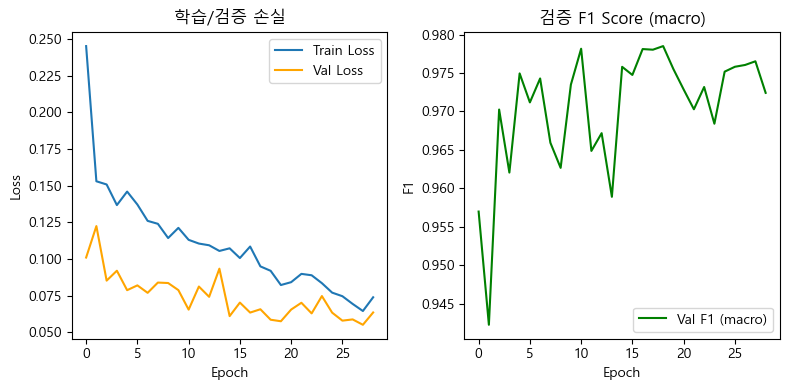

In [5]:
# ________________________________________
# [파이프라인 단계 5] Stage1 학습 곡선 시각화
# ________________________________________

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss', color='orange')
ax1.set(title='학습/검증 손실', xlabel='Epoch', ylabel='Loss')
ax1.legend()

ax2.plot(val_f1s, color='green', label='Val F1 (macro)')
ax2.set(title='검증 F1 Score (macro)', xlabel='Epoch', ylabel='F1')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curve.png')
plt.show()

## 학습 곡선 해석
- **Train Loss**는 전반적으로 감소하여 모델이 학습 데이터 패턴을 안정적으로 학습하고 있음.
- **Val Loss**도 함께 감소하며 후반부에는 약 `0.06` 근처로 수렴해 일반화 성능이 유지됨.
- **Val F1 (macro)**는 초반 변동 이후 `0.97~0.98` 구간에서 안정화되어 클래스 불균형 상황에서도 성능이 양호함.
- Train/Val 간 격차가 크게 벌어지지 않아 과적합 징후는 제한적이며, 현재 설정(드롭아웃 + early stopping)이 적절하게 작동한 것으로 보임.

요약: 학습은 안정적으로 수렴했고, 검증 성능도 높은 수준에서 유지되어 현재 모델을 기준 모델(Stage1)로 사용하기에 충분함.

In [ ]:
# ________________________________________
# [파이프라인 단계 6] Stage1 검증/테스트 평가
# ________________________________________

from models.model_config import evaluate
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_mlp_model.pth'))
model.eval()
# 저장된 best 모델 기준으로 val/test를 모두 평가
test_preds, test_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        test_preds.extend(model(X_b).argmax(1).cpu().numpy())
        test_labels.extend(y_b.cpu().numpy())



val_preds, val_labels = [], []
with torch.no_grad():
    for X_b, y_b in val_loader:
        val_preds.extend(model(X_b).argmax(1).cpu().numpy())
        val_labels.extend(y_b.cpu().numpy())

evaluate(val_labels, val_preds, test_labels, test_preds, model_name='MLP', OUTPUT_DIR=OUTPUT_DIR)

MLP evaluation 결과가 C:\Users\user\Documents\GitHub\Team-3\models\MLP\MLP_evaluation.txt에 저장되었습니다.
  MLP validation 평가 결과
Accuracy   : 0.9788
F1 macro   : 0.9785
F1 weighted: 0.9787
              precision    recall  f1-score   support

           0     0.9803    0.9969    0.9885      2294
           1     0.9807    0.9604    0.9704      2273
           2     0.9742    0.9788    0.9765      1700

    accuracy                         0.9788      6267
   macro avg     0.9784    0.9787    0.9785      6267
weighted avg     0.9788    0.9788    0.9787      6267

  MLP test 평가 결과
Accuracy   : 0.9748
F1 macro   : 0.9751
F1 weighted: 0.9747
              precision    recall  f1-score   support

           0     0.9711    0.9924    0.9817      2238
           1     0.9785    0.9534    0.9658      2341
           2     0.9747    0.9810    0.9779      1688

    accuracy                         0.9748      6267
   macro avg     0.9748    0.9756    0.9751      6267
weighted avg     0.9749    0.9748   

## Stage1 평가 결과 간단 분석
- Validation과 Test 지표가 모두 높은 수준으로 확인되어 Stage1 모델의 기본 성능은 안정적임.
- Accuracy와 F1 macro 간 차이가 크지 않아, 특정 클래스 한쪽으로만 치우친 성능 저하는 크지 않은 것으로 해석할 수 있음.
- 다만 이후 개선 단계에서 확인하듯, 2단계(중간 단계) 관련 오분류는 상대적으로 더 발생할 수 있어 Two-Stage 보정의 효과를 함께 보는 것이 중요함.

### 참고 (경고 메시지)
- `torch.load`의 `FutureWarning`은 보안/기본값 변경 예고이며, 현재 실험 결과 자체를 무효화하는 오류는 아님.
- 추후에는 `torch.load(..., weights_only=True)` 적용을 검토하면 경고를 줄일 수 있음.

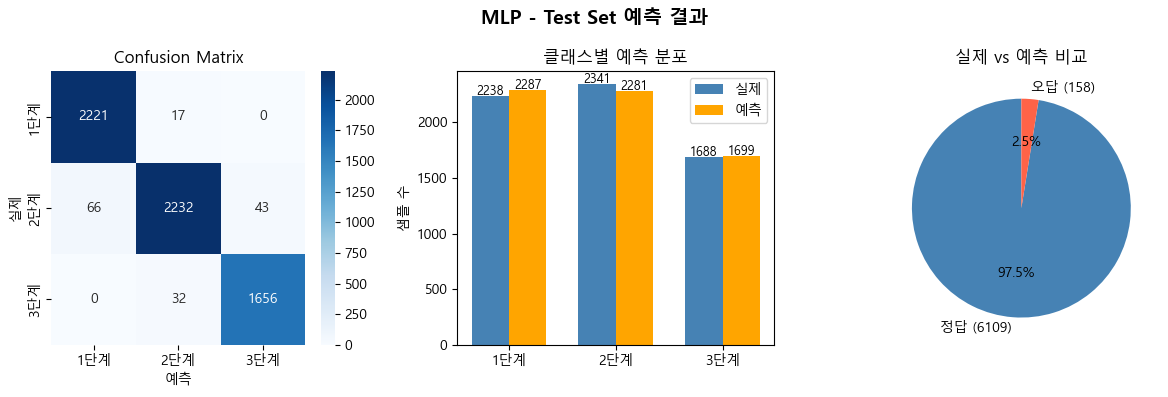

In [7]:
# ________________________________________
# [파이프라인 단계 7] Stage1 예측 결과 시각화
# ________________________________________

import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ['1단계', '2단계', '3단계']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Confusion Matrix
sns.heatmap(confusion_matrix(test_labels, test_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set(title='Confusion Matrix', xlabel='예측', ylabel='실제')

# 2. 클래스별 실제/예측 샘플 수 비교
actual_counts = [test_labels.count(i) for i in range(3)]
pred_counts   = [test_preds.count(i)  for i in range(3)]
x, w = np.arange(3), 0.35
axes[1].bar(x - w/2, actual_counts, w, label='실제', color='steelblue')
axes[1].bar(x + w/2, pred_counts,   w, label='예측', color='orange')
axes[1].set(xticks=x, xticklabels=class_names, title='클래스별 예측 분포', ylabel='샘플 수')
axes[1].legend()
for i, (a, p) in enumerate(zip(actual_counts, pred_counts)):
    axes[1].text(i - w/2, a + 10, str(a), ha='center', fontsize=9)
    axes[1].text(i + w/2, p + 10, str(p), ha='center', fontsize=9)

# 3. 전체 정답/오답 비율 파이차트
correct_n   = sum(t == p for t, p in zip(test_labels, test_preds))
incorrect_n = len(test_labels) - correct_n
axes[2].pie([correct_n, incorrect_n],
            labels=[f'정답 ({correct_n})', f'오답 ({incorrect_n})'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[2].set_title('실제 vs 예측 비교')

plt.suptitle('MLP - Test Set 예측 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'MLP_prediction_results.png', dpi=300)
plt.show()

## Test 시각화 결과 분석
### 1) Confusion Matrix 해석
- 대각선 값이 매우 커서 전체적으로 올바른 분류 비율이 높음.
- 1단계와 3단계는 오분류가 상대적으로 적고 안정적으로 분류됨.
- 주요 오분류는 **2단계에서 1단계/3단계로 이동**하는 패턴으로 나타남(2단계 경계 샘플의 난이도가 높음).

### 2) 클래스별 실제/예측 막대그래프 해석
- 1단계: 예측 수가 실제보다 약간 많아지는 경향이 보임.
- 2단계: 예측 수가 실제보다 적어져, 일부 샘플이 인접 단계로 이동했음을 시사함.
- 3단계: 예측 수가 실제보다 다소 많아, 2단계 일부가 3단계로 예측되는 경향과 일치함.

### 3) 정답/오답 파이차트 해석
- 정답 비율이 약 97%대로 매우 높아 모델의 기본 분류 성능은 우수함.
- 오답 비율은 약 2~3% 수준으로 낮지만, 실무 관점에서는 2단계 관련 오류를 우선 개선 대상으로 볼 수 있음.

### 4) 통합 결론
- Stage1 MLP는 전반적으로 높은 성능을 보이며 기본 모델로 충분히 타당함.
- 성능 병목은 **2단계 경계 구간 오분류**에 집중되어 있으므로,
  **경계 샘플에 한정한 Two-Stage 보정 전략**이 합리적인 다음 단계임.

## 개선 방법/결과 요약

### 1) 방법
1. 현재 오분류율을 먼저 점검함.
2. Stage1 MLP의 예측 확률에서 top1-top2 margin이 작은 샘플을 경계 샘플로 정의함.
3. 경계 샘플에 대해서만 2단계 보정기를 적용해 최종 클래스를 재판정함.
4. 2단계 보정기는 0↔1, 1↔2 이진 LogisticRegression으로 구성함.
5. 보정은 경계쌍(0,1)/(1,2)이면서 margin < threshold 조건에서만 수행함.
6. threshold는 Validation에서 성능 지표가 더 이상 개선되지 않을 때까지 자동 탐색함.

### 2) 현재 실행 결과 
- Threshold 탐색 구간: 0.03 ~ 0.95 (step=0.01)
- 선택된 threshold: **0.87**
- 선택 시 Validation 지표:
  - Accuracy: **0.9946**
  - F1 macro: **0.9946**
  - Recall(2단계): **0.9886**
  - Reclassified count (val): **879**

### 3) Test 성능 비교 
| 지표 | Stage1 MLP | Two-Stage | 변화 |
|---|---:|---:|---:|
| Accuracy | 0.9748 | 0.9936 | +0.0188 |
| F1 macro | 0.9751 | 0.9936 | +0.0185 |
| Recall(2단계) | 0.9534 | 0.9868 | +0.0334 |

### 4) Confusion Matrix 수치
Stage1 MLP
| 실제 \ 예측 | 1단계 | 2단계 | 3단계 |
|---|---:|---:|---:|
| 1단계 | 2221 | 17 | 0 |
| 2단계 | 66 | 2232 | 43 |
| 3단계 | 0 | 32 | 1656 |

Two-Stage (th=0.87)
| 실제 \ 예측 | 1단계 | 2단계 | 3단계 |
|---|---:|---:|---:|
| 1단계 | 2234 | 4 | 0 |
| 2단계 | 13 | 2310 | 18 |
| 3단계 | 0 | 5 | 1683 |

### 5) 해석
- Stage1 대비 Two-Stage에서 Accuracy/F1/Recall(2단계)가 모두 개선됨.
- 특히 2단계 관련 오분류(2→1, 2→3)가 크게 감소함.
- 경계 샘플 선택 보정이 성능 개선에 유의미하게 기여한 것으로 해석됨.

### 6) 재현 참고
- 위 수치는 `MLP_two_stage_comparison.csv`, `MLP_two_stage_val_threshold_tuning.csv` 및 confusion matrix 출력 기준임.
- 모델/데이터 상태가 바뀌면 수치도 함께 갱신됨.

In [8]:
# ________________________________________
# [파이프라인 단계 8] 개선 실험 준비: Baseline 오분류 분석
# ________________________________________
# ---------- 개선 단계 ----------
# [개선 단계 0] Baseline(1단계 모델) 오분류 현황 점검

# 예측 벡터 선택 (bias tuning 결과 있으면 우선 사용)
if 'selected_bias_preds' in globals() and 'selected_bias_labels' in globals():
    y_true = np.array(selected_bias_labels)
    y_pred = np.array(selected_bias_preds)
    tag = f"bias_tuning_{selected_bias:+.2f}" if 'selected_bias' in globals() else 'bias_tuning'
elif 'test_labels' in globals() and 'test_preds' in globals():
    y_true, y_pred, tag = np.array(test_labels), np.array(test_preds), 'baseline'
else:
    raise RuntimeError('예측 결과 변수가 없습니다. 평가 셀을 먼저 실행하세요.')

analysis_df = test_df.copy().reset_index(drop=True)
analysis_df['actual']     = y_true
analysis_df['pred']       = y_pred
analysis_df['actual_stage'] = y_true + 1
analysis_df['pred_stage']   = y_pred + 1
analysis_df['is_correct'] = y_true == y_pred

mis_df = analysis_df[~analysis_df['is_correct']]
acc_now = analysis_df['is_correct'].mean()

print(f'[{tag}] 정확도: {acc_now:.4f} | 오분류: {len(mis_df)}/{len(analysis_df)}')

print('\n[오분류 이동 패턴만]')
display(pd.crosstab(mis_df['actual_stage'], mis_df['pred_stage'],
                    rownames=['실제 단계'], colnames=['예측 단계']))

print('\n[단계별 오분류율]')
stage_summary = (
    analysis_df.groupby('actual_stage', as_index=False)
    .agg(total=('actual_stage','count'), correct=('is_correct','sum'))
)
stage_summary['misclassified'] = stage_summary['total'] - stage_summary['correct']
stage_summary['error_rate']    = stage_summary['misclassified'] / stage_summary['total']
display(stage_summary.round(4))

[baseline] 정확도: 0.9748 | 오분류: 158/6267

[오분류 이동 패턴만]


예측 단계,1,2,3
실제 단계,,,
1,0,17,0
2,66,0,43
3,0,32,0



[단계별 오분류율]


,actual_stage,total,correct,misclassified,error_rate
0,1,2238,2221,17,0.0076
1,2,2341,2232,109,0.0466
2,3,1688,1656,32,0.0190


[Validation threshold tuning 결과]


,threshold,val_accuracy,val_f1_macro,val_recall_stage2,reclassified_count
0,0.03,0.9797,0.9794,0.9622,19
1,0.04,0.9802,0.9799,0.9635,25
2,0.05,0.9805,0.9802,0.9635,28
3,0.06,0.9807,0.9804,0.9635,32
4,0.07,0.9807,0.9804,0.9635,38
...,...,...,...,...,...
88,0.91,0.9946,0.9946,0.9886,1062
89,0.92,0.9946,0.9946,0.9886,1102
90,0.93,0.9946,0.9946,0.9886,1158
91,0.94,0.9946,0.9946,0.9886,1231


선택 threshold: 0.87

[Test 개선 전/후 비교]


,Model,Accuracy,F1_macro,Recall_2단계,Delta_Accuracy,Delta_F1_macro,Delta_Recall_2단계
0,Stage1 MLP,0.9748,0.9751,0.9534,NaN,NaN,NaN
1,Two-Stage (Boundary Reclass),0.9936,0.9936,0.9868,0.0188,0.0185,0.0333


재분류된 샘플 수(test): 896


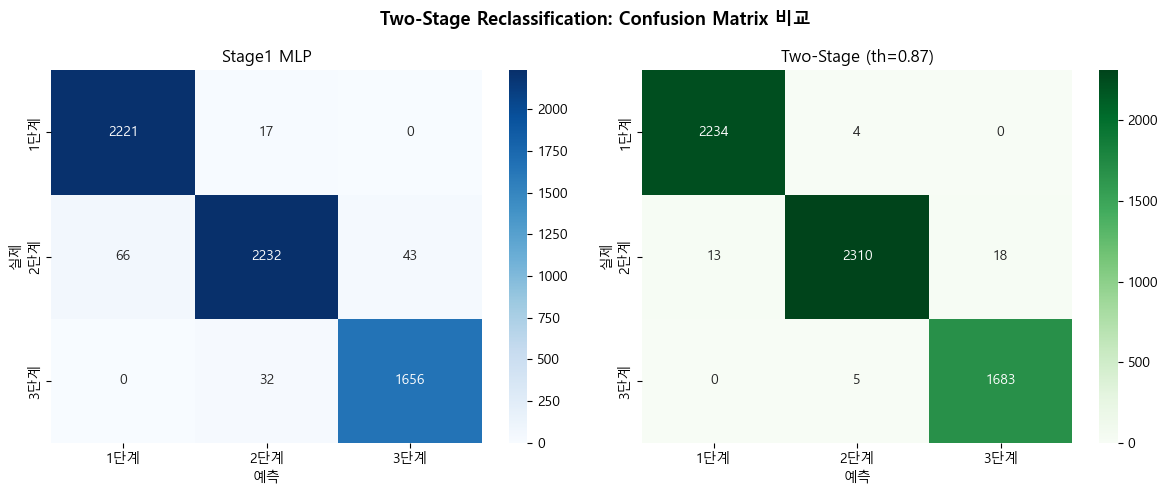


[저장 완료]


In [9]:
# ________________________________________
# [파이프라인 단계 8] 개선 실험 실행: Two-Stage 보정
# ________________________________________
# ---------- 개선 단계(분리) ----------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, confusion_matrix

feature_cols = [c for c in MODEL_FEATURES if c in train_df.columns]
assert feature_cols, 'MODEL_FEATURES가 데이터프레임 컬럼과 일치하지 않습니다.'

# [개선 단계 1] Stage1 MLP 확률 예측 생성
stage1_model = MLP(input_dim=len(features), output_dim=3)
stage1_model.load_state_dict(torch.load(OUTPUT_DIR / 'best_mlp_model.pth'))
stage1_model.eval()

def get_probs(model, loader):
    probs, labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            probs.append(torch.softmax(model(X_b), dim=1).cpu().numpy())
            labels.append(y_b.cpu().numpy())
    return np.vstack(probs), np.concatenate(labels)

val_probs,  val_true  = get_probs(stage1_model, val_loader)
test_probs, test_true = get_probs(stage1_model, test_loader)
test_pred_stage1 = np.argmax(test_probs, axis=1)

# [개선 단계 3] 2단계 보정기(0↔1, 1↔2) 학습: 이진 LogisticRegression
def train_binary_clf(df, cls_a, cls_b):
    sub = df[df['digital_stage'].isin([cls_a, cls_b])]
    X = sub[feature_cols].values
    y = (sub['digital_stage'].values == cls_b).astype(int)
    clf = LogisticRegression(max_iter=2000, class_weight='balanced')
    clf.fit(X, y)
    return clf

clf_01 = train_binary_clf(train_df, 0, 1)
clf_12 = train_binary_clf(train_df, 1, 2)

# [개선 단계 2 + 4] 경계 샘플 선별 및 조건부 보정 적용
def apply_two_stage(df, probs, threshold):
    final_pred = np.argmax(probs, axis=1).copy()
    X_all = df[feature_cols].values
    n_re = 0
    for i, prob_row in enumerate(probs):
        order = np.argsort(prob_row)[::-1]
        c1, c2 = int(order[0]), int(order[1])
        margin = float(prob_row[c1] - prob_row[c2])

        # [개선 단계 2] margin이 작은 경계 샘플만 후보로 선택
        # [개선 단계 4] 경계쌍(0,1)/(1,2) + margin<threshold 조건에서만 보정
        if margin >= threshold or {c1, c2} not in ({0,1}, {1,2}):
            continue

        x = X_all[i].reshape(1, -1)
        if {c1, c2} == {0, 1}:
            final_pred[i] = clf_01.predict(x)[0]
        else:
            final_pred[i] = 1 + clf_12.predict(x)[0]
        n_re += 1
    return final_pred, n_re

# [개선 단계 5] Validation에서 threshold 탐색 후 최적값 선택
val_rows = []
baseline_preds = np.argmax(val_probs, axis=1)
baseline_metrics = (
    accuracy_score(val_true, baseline_preds),
    f1_score(val_true, baseline_preds, average='macro'),
    recall_score(val_true, baseline_preds, labels=[1], average='macro', zero_division=0),
)
best_metrics = baseline_metrics
best_th = 0.0
patience = 8
no_improve_count = 0
threshold = 0.03
threshold_step = 0.01
max_threshold = 1.00

while threshold <= max_threshold:
    preds, n_re = apply_two_stage(val_df.reset_index(drop=True), val_probs, threshold)
    current_metrics = (
        accuracy_score(val_true, preds),
        f1_score(val_true, preds, average='macro'),
        recall_score(val_true, preds, labels=[1], average='macro', zero_division=0),
    )
    val_rows.append({
        'threshold':          threshold,
        'val_accuracy':       current_metrics[0],
        'val_f1_macro':       current_metrics[1],
        'val_recall_stage2':  current_metrics[2],
        'reclassified_count': n_re,
    })

    if best_metrics is None or current_metrics > best_metrics:
        best_metrics = current_metrics
        best_th = threshold
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            break

    threshold = round(threshold + threshold_step, 4)

val_tune_df = pd.DataFrame(val_rows).sort_values('threshold').reset_index(drop=True)

print('[Validation threshold tuning 결과]')
display(val_tune_df.round(4))
print(f'선택 threshold: {best_th:.2f}')

# 선택한 threshold로 Test 적용 및 비교
test_pred_2stage, test_reclassified = apply_two_stage(
    test_df.reset_index(drop=True), test_probs, best_th)

def scores(true, pred):
    return (accuracy_score(true, pred),
            f1_score(true, pred, average='macro'),
            recall_score(true, pred, labels=[1], average='macro', zero_division=0))

b_acc, b_f1, b_rec = scores(test_true, test_pred_stage1)
a_acc, a_f1, a_rec = scores(test_true, test_pred_2stage)

compare_df = pd.DataFrame([
    {'Model': 'Stage1 MLP',                 'Accuracy': b_acc, 'F1_macro': b_f1, 'Recall_2단계': b_rec},
    {'Model': 'Two-Stage (Boundary Reclass)','Accuracy': a_acc, 'F1_macro': a_f1, 'Recall_2단계': a_rec,
     'Delta_Accuracy': a_acc-b_acc, 'Delta_F1_macro': a_f1-b_f1, 'Delta_Recall_2단계': a_rec-b_rec},
])
print('\n[Test 개선 전/후 비교]')
display(compare_df.round(4))
print(f'재분류된 샘플 수(test): {test_reclassified}')

# Confusion matrix 저장
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_kr = ['1단계', '2단계', '3단계']
for ax, cm, title, cmap in [
    (axes[0], confusion_matrix(test_true, test_pred_stage1), 'Stage1 MLP',                   'Blues'),
    (axes[1], confusion_matrix(test_true, test_pred_2stage), f'Two-Stage (th={best_th:.2f})', 'Greens'),
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels_kr, yticklabels=labels_kr, ax=ax)
    ax.set(title=title, xlabel='예측', ylabel='실제')

plt.suptitle('Two-Stage Reclassification: Confusion Matrix 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_img_path = OUTPUT_DIR / 'MLP_two_stage_confusion_matrix.png'
plt.savefig(cm_img_path, dpi=300)
plt.show()

# 저장
compare_df.to_csv(OUTPUT_DIR / 'MLP_two_stage_comparison.csv',           index=False, encoding='utf-8-sig')
val_tune_df.to_csv(OUTPUT_DIR / 'MLP_two_stage_val_threshold_tuning.csv', index=False, encoding='utf-8-sig')
print('\n[저장 완료]')

결과 해석은 위의 개선 방법과 함께 정리해놓았습니다.